# Heart Failure Prediction Dataset

**Ссылка для скачивания:**  
<https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/data>

### О датасете
- **918 записей**, 11 клинических признаков
- **Целевая переменная:** `HeartDisease` (1 — есть заболевание, 0 — нет)
- Объединяет **5 датасетов**: Cleveland, Hungarian, Switzerland, Long Beach VA, Stalog
- **Пропусков нет**, но в ходе EDA обнаружится другая проблема
- **Задача:** бинарная классификация для раннего выявления сердечно-сосудистых заболеваний

### Описание признаков

| Признак | Описание | Тип |
|---------|----------|-----|
| **Age** | Возраст (годы) | Числовой |
| **Sex** | Пол (M: Мужской, F: Женский) | Категориальный |
| **ChestPainType** | Тип боли в груди (TA: Типичная стенокардия, ATA: Атипичная стенокардия, NAP: Неангинальная боль, ASY: Бессимптомно) | Категориальный |
| **RestingBP** | Артериальное давление в покое (мм рт.ст.) |Числовой |
| **Cholesterol** | Холестерин (мм/дл) | Числовой |
| **FastingBS** | Сахар в крови натощак (1: если > 120 мг/дл, 0: иначе) | Бинарный |
| **RestingECG** | Результаты ЭКГ в покое (Normal: Норма, ST: Аномалия зубца ST-T, LVH: Гипертрофия левого желудочка) | Категориальный |
| **MaxHR** | Макс. ЧСС (60-202) | Числовой |
| **ExerciseAngina** | Стенокардия при нагрузке (Y: Да, N: Нет) | Бинарный (категориальный) |
| **Oldpeak** | Депрессия ST (мм) | Числовой |
| **ST_Slope** | Наклон ST (Up: восходящий, Flat: плоский, Down: нисходящий) | Категориальный |
| **HeartDisease** | Целевая переменная (1: есть болезнь сердца, 0: норма) | Бинарный |

### A) Быстрый обзор данных (Pandas)

In [69]:
#импорт бибилотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

#загрузка данных
df = pd.read_csv("heart.csv")

`df.head()`

In [70]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


`df.tail()`

In [71]:
df.tail(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
908,63,M,ASY,140,187,0,LVH,144,Y,4.0,Up,1
909,63,F,ASY,124,197,0,Normal,136,Y,0.0,Flat,1
910,41,M,ATA,120,157,0,Normal,182,N,0.0,Up,0
911,59,M,ASY,164,176,1,LVH,90,N,1.0,Flat,1
912,57,F,ASY,140,241,0,Normal,123,Y,0.2,Flat,1
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


`df.shape`

In [72]:
df.shape

(918, 12)

Общая информация о датасете\
`df.info()`

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


`df.describe()`

In [74]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Отдельно `df.describe(include="object")`

In [75]:
df.describe(include=["object", "string"])

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


`isnull().sum()`

In [76]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

### B) Пропуски и очистка

Значение **min** показателей **RestingBP** (Артериальное давление в покое) и **Cholesterol** (Холестерин) равны 0, что невозможно, посчитаем количество таких колонок

In [77]:
print("RestingBP zeros:", (df["RestingBP"] == 0).sum())
print("Cholesterol zeros:", (df["Cholesterol"] == 0).sum())

RestingBP zeros: 1
Cholesterol zeros: 172


Так как имеется только одна запись содержит **RestingBP = 0**, её можно спокойно удалить, так как это лишь 1 из 918 записей

In [78]:
df = df[df["RestingBP"] > 0]

Количество записей с **Cholesterol = 0** равно 172, что уже является заметной долей в данных, 172/917 = 18.75%, просто так удалить их нельзя.\
Посмотрим распределение нулей по нашему целевому признаку **HeartDisease** чтобы понять, есть ли между ними какая-то связь

In [79]:
print("Распределение нулей по целевому признаку:")
print(df.groupby('HeartDisease')['Cholesterol'].apply(lambda x: (x==0).sum()))

Распределение нулей по целевому признаку:
HeartDisease
0     20
1    151
Name: Cholesterol, dtype: int64


Видим, что 151/172 = 87.7% нулей у пациентов с обнаруженными сердечными заболеваниями. Создадим новый признак **Cholesterol_missing** который будет указывать, равно ли значение **Cholesterol** нулю

In [80]:
df["Cholesterol_missing"] = (df["Cholesterol"] == 0).astype(int)

In [81]:
median_ill = df[df["HeartDisease"] == 1]["Cholesterol"].median()
median_healty = df[df["HeartDisease"] == 0]["Cholesterol"].median()

print(f"Медиана холестерина у больных: {median_ill:.0f}")
print(f"Медиана холестерина у здоровых: {median_healty:.0f}")

Медиана холестерина у больных: 217
Медиана холестерина у здоровых: 227


Заполняем нули раздельно, потому что у 151 больного нет холестерина, а у здоровых только 20 - если всем поставить общую медиану, мы больным завысим показатель, а здоровым занизим, и модель запутается. Поэтому больным с пропуском ставим медиану холестерина больных, здоровым с пропуском - медиану здоровых. Флаг **Cholesterol_missing** нужен, чтобы показать модели, что значение восстановленное, а не реальное - сам факт пропуска (особенно у больных) тоже важная информация.

In [82]:
df.loc[(df['Cholesterol'] == 0) & (df['HeartDisease'] == 1), 'Cholesterol'] = median_ill
df.loc[(df['Cholesterol'] == 0) & (df['HeartDisease'] == 0), 'Cholesterol'] = median_healty

`df.describe()` после проиведенных манипуляций

In [83]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Cholesterol_missing
count,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000
mean,53.509269,132.540894,239.700109,0.233370,136.789531,0.886696,0.552890,0.186478
std,9.437636,17.999749,54.352727,0.423206,25.467129,1.066960,0.497466,0.389704
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,225.000000,0.000000,138.000000,0.600000,1.000000,0.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000,0.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000,1.000000


### C) Расширенная статистика
Для числовых колонок выведем: min, max, mean, median, mode\
Посчитаем quantile.

In [84]:
num_cols = df.select_dtypes(include=[np.number]).columns

stats = df[num_cols].describe().T

for col in num_cols:
    stats.loc[col, "mode"] = df[col].mode()[0]

for col in num_cols:
    stats.loc[col, "5%"] = df[col].quantile(0.05)
    stats.loc[col, "95%"] = df[col].quantile(0.95)

stats = stats[['min', '5%', '25%', '50%', '75%', '95%', 'max', 'mean', 'mode']]
stats.columns = ['min', '5%', '25%', 'median', '75%', '95%', 'max', 'mean', 'mode']

print(stats.round(2))

                      min     5%    25%  median    75%    95%    max    mean   mode
Age                  28.0   37.0   47.0    54.0   60.0   68.0   77.0   53.51   54.0
RestingBP            80.0  107.6  120.0   130.0  140.0  160.0  200.0  132.54  120.0
Cholesterol          85.0  168.0  214.0   225.0  267.0  331.4  603.0  239.70  217.0
FastingBS             0.0    0.0    0.0     0.0    0.0    1.0    1.0    0.23    0.0
MaxHR                60.0   96.0  120.0   138.0  156.0  178.0  202.0  136.79  150.0
Oldpeak              -2.6    0.0    0.0     0.6    1.5    3.0    6.2    0.89    0.0
HeartDisease          0.0    0.0    0.0     1.0    1.0    1.0    1.0    0.55    1.0
Cholesterol_missing   0.0    0.0    0.0     0.0    0.0    1.0    1.0    0.19    0.0


Посчитаем дисперсию (variance), асимметрию (skewness) и эксцесс (kurtosis)

In [85]:
from scipy.stats import skew, kurtosis

stats_advanced = pd.DataFrame(index=num_cols)

for col in num_cols:
    stats_advanced.loc[col, 'Variance'] = df[col].var()
    stats_advanced.loc[col, 'Skewness'] = skew(df[col])
    stats_advanced.loc[col, 'Kurtosis'] = kurtosis(df[col])

print(stats_advanced.round(2))

                     Variance  Skewness  Kurtosis
Age                     89.07     -0.20     -0.39
RestingBP              323.99      0.61      0.78
Cholesterol           2954.22      1.55      6.07
FastingBS                0.18      1.26     -0.41
MaxHR                  648.57     -0.14     -0.45
Oldpeak                  1.14      1.02      1.19
HeartDisease             0.25     -0.21     -1.95
Cholesterol_missing      0.15      1.61      0.59


**Что это значит** для наших данных?\
**Age (Возраст):**
- Skewness (-0.20): Близка к нулю, отрицательная. Распределение почти симметричное, лишь слегка смещенное влево, *mean* меньше *median* (возможно, немного больше молодых пациентов).
- Kurtosis (-0.39): Близка к нулю, отрицательная. Распределение возраста очень близко к нормальному, немного более плоское, чем идеальный колокол, выбросов нет.

**RestingBP (Артериальное давление в покое):**
- Skewness (0.61): Положительная асимметрия. Распределение давления немного смещено вправо. Это означает, что есть некоторое количество пациентов с давлением выше среднего, что удлиняет правый хвост.
- Kurtosis (0.78): Близкий к нормальному, но с чуть более острым пиком. Выбросов, сильно влияющих на форму, мало.

**Cholesterol (Холестерин):**
- Variance (2954.22): Огромный разброс. Значения холестерина варьируются от очень низких до экстремально высоких (603). Это говорит о большой неоднородности пациентов по этому показателю.
- Skewness (1.55): Сильная положительная асимметрия (правосторонняя). Основная масса пациентов имеет холестерин в районе 200–250, но существует "длинный хвост" из пациентов с очень высокими значениями (под 600). Среднее значение (239.7) будет выше медианы (225) именно из-за этого хвоста.
- Kurtosis (6.07): Очень острый пик (лептокуртическое распределение). Это указывает на то, что данные очень тесно сгруппированы вокруг центра (медианы/среднего), но из-за наличия выбросов (603) имеет острый пик.

**FastingBS (Уровень сахара в крови):**\
Для бинарных признаков (0/1) эти метрики имеют другое значение. Они показывают, что распределение состоит из двух пиков (0 и 1).
- Skewness (1.26): Положительная асимметрия говорит о том, что значений "0" (норма) значительно больше, чем "1" (повышенный сахар).
- Kurtosis (-0.41): Отрицательный эксцесс - это нормально для бинарного признака, он указывает на два пика.

**MaxHR (Макс. ЧСС):**
- Skewness (-0.14): Около нуля, слегка отрицательная. Распределение практически симметричное.
- Kurtosis (-0.45): Около нуля, немного плоское. Тоже близко к нормальному распределению.

**Oldpeak (Депрессия ST):**
- Skewness (1.02): Положительная асимметрия. Большинство пациентов имеют низкие значения Oldpeak (0–1.5), что говорит об отсутствии серьезной депрессии ST. Но есть группа пациентов с высокими значениями (>3), которые, вероятно, и являются основными носителями болезни.
- Kurtosis (1.19): Острый пик. Это подтверждает, что значения сконцентрированы вокруг нуля, и есть те самые "тяжелые" пациенты на правом хвосте.

**HeartDisease (Целевая переменная):**
- Skewness (-0.21): Легкая отрицательная асимметрия говорит о том, что единиц (больных) чуть больше, чем нулей (здоровых) - что мы и видели.
- Kurtosis (-1.95): Отрицательный эксцесс - это нормально для бинарного признака, он указывает на два пика.

**Cholesterol_missing (Холестерин был равен нулю):**
- Skewness (1.61), Kurtosis (0.59): Положительная асимметрия и положительный эксцесс. Это означает, что большинство значений - 0 (пропуска не было), но есть устойчивая группа из 151 пациента, у которых пропуск был. Это создает небольшой "пик" из единиц, что и дает положительный эксцесс.

### D) Фичи: Энкодинг и Инжиниринг (Feature Engineering)
Кодирование категориальных признаков: pd.get_dummies

In [86]:
сat_cols = df.select_dtypes(include=["object", "string"]).columns

print("До кодирования:")
print(df.head())

До кодирования:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease  Cholesterol_missing
0   40   M           ATA        140          289          0     Normal    172              N      0.0       Up             0                    0
1   49   F           NAP        160          180          0     Normal    156              N      1.0     Flat             1                    0
2   37   M           ATA        130          283          0         ST     98              N      0.0       Up             0                    0
3   48   F           ASY        138          214          0     Normal    108              Y      1.5     Flat             1                    0
4   54   M           NAP        150          195          0     Normal    122              N      0.0       Up             0                    0


In [87]:
df_encoded = pd.get_dummies(df, columns=сat_cols, drop_first=False, dtype=int)

print("\n После кодирования:")
print(df_encoded.head())
print(f"\nРазмерность изменилась: {df.shape} → {df_encoded.shape}")


 После кодирования:
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  Cholesterol_missing  Sex_F  Sex_M  ChestPainType_ASY  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  RestingECG_LVH  \
0   40        140          289          0    172      0.0             0                    0      0      1                  0                  1                  0                 0               0   
1   49        160          180          0    156      1.0             1                    0      1      0                  0                  0                  1                 0               0   
2   37        130          283          0     98      0.0             0                    0      0      1                  0                  1                  0                 0               0   
3   48        138          214          0    108      1.5             1                    0      1      0                  1                  0                  0            

Генерация новых фич

In [88]:
df_features = df_encoded.copy()

# Признак 1: Произведение возраста и Oldpeak (чем старше + выше депрессия = хуже)
df_features["Age_Oldpeak"] = df_features["Age"] * df_features["Oldpeak"]

# Признак 2: Разница между MaxHR и возрастом
df_features["MaxHR_Age_Diff"] = df_features["MaxHR"] - df_features["Age"]

# Признак 3: Отношение холестерина к возрасту
df_features['Chol_Per_Age'] = df['Cholesterol'] / (df['Age'] + 1e-5)  # защита от деления на 0

df = df_features.copy()

Датасет с новыми признаками

In [89]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Cholesterol_missing,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Age_Oldpeak,MaxHR_Age_Diff,Chol_Per_Age
count,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000
mean,53.509269,132.540894,239.700109,0.233370,136.789531,0.886696,0.552890,0.186478,0.210469,0.789531,0.540894,0.188659,0.220284,0.050164,0.205016,0.600872,0.194111,0.595420,0.404580,0.068702,0.500545,0.430752,50.047219,83.280262,4.629911
std,9.437636,17.999749,54.352727,0.423206,25.467129,1.066960,0.497466,0.389704,0.407864,0.407864,0.498597,0.391451,0.414664,0.218401,0.403934,0.489986,0.395731,0.491078,0.491078,0.253085,0.500273,0.495452,61.769516,30.354654,1.391205
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-119.600000,2.000000,1.486842
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,61.000000,3.687499
50%,54.000000,130.000000,225.000000,0.000000,138.000000,0.600000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,30.000000,83.000000,4.322580
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,86.800000,105.000000,5.282608
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,384.400000,173.000000,16.531245


### E) Визуализация!!

Распределения: гистограммы / KDE.

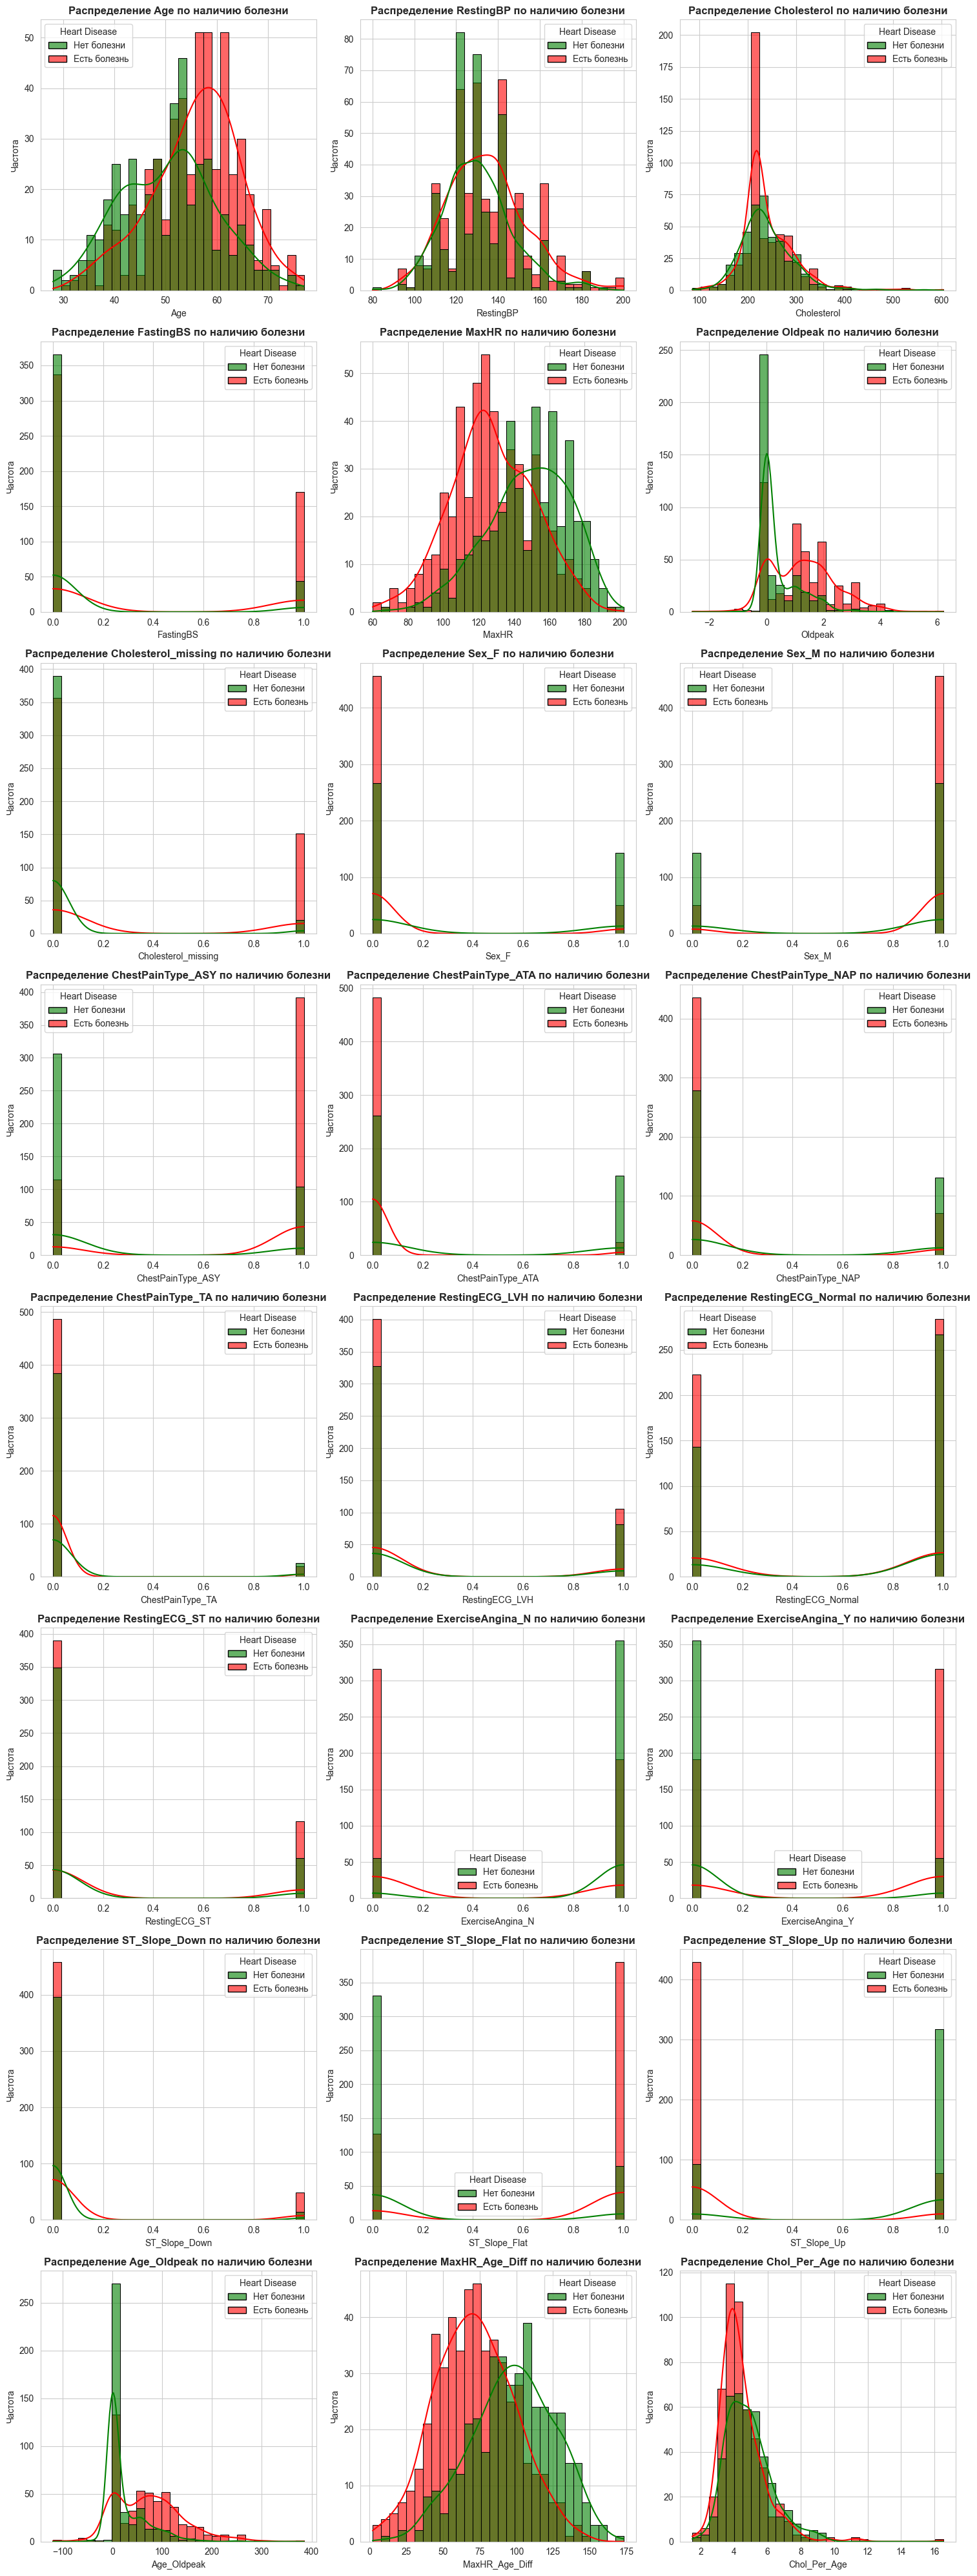

In [90]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 10)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if 'HeartDisease' in num_cols:
    num_cols.remove('HeartDisease')

# Создаем сетку графиков
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if i < len(axes):
        # Гистограмма с KDE и разделением по целевому признаку
        sns.histplot(data=df, x=col, hue='HeartDisease', kde=True,
                     ax=axes[i], palette=['green', 'red'], 
                     alpha=0.6, bins=30, edgecolor='black')
        
        # Настройка заголовка и подписей
        axes[i].set_title(f'Распределение {col} по наличию болезни', 
                         fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col, fontsize=10)
        axes[i].set_ylabel('Частота', fontsize=10)
        
        legend = axes[i].legend_
        if legend:
            legend.set_title('Heart Disease')
            for text, label in zip(legend.get_texts(), ['Нет болезни', 'Есть болезнь']):
                text.set_text(label)

# Скрываем лишние графики
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Box plot (ящик с усами) - ищем аномалии/выбросы.

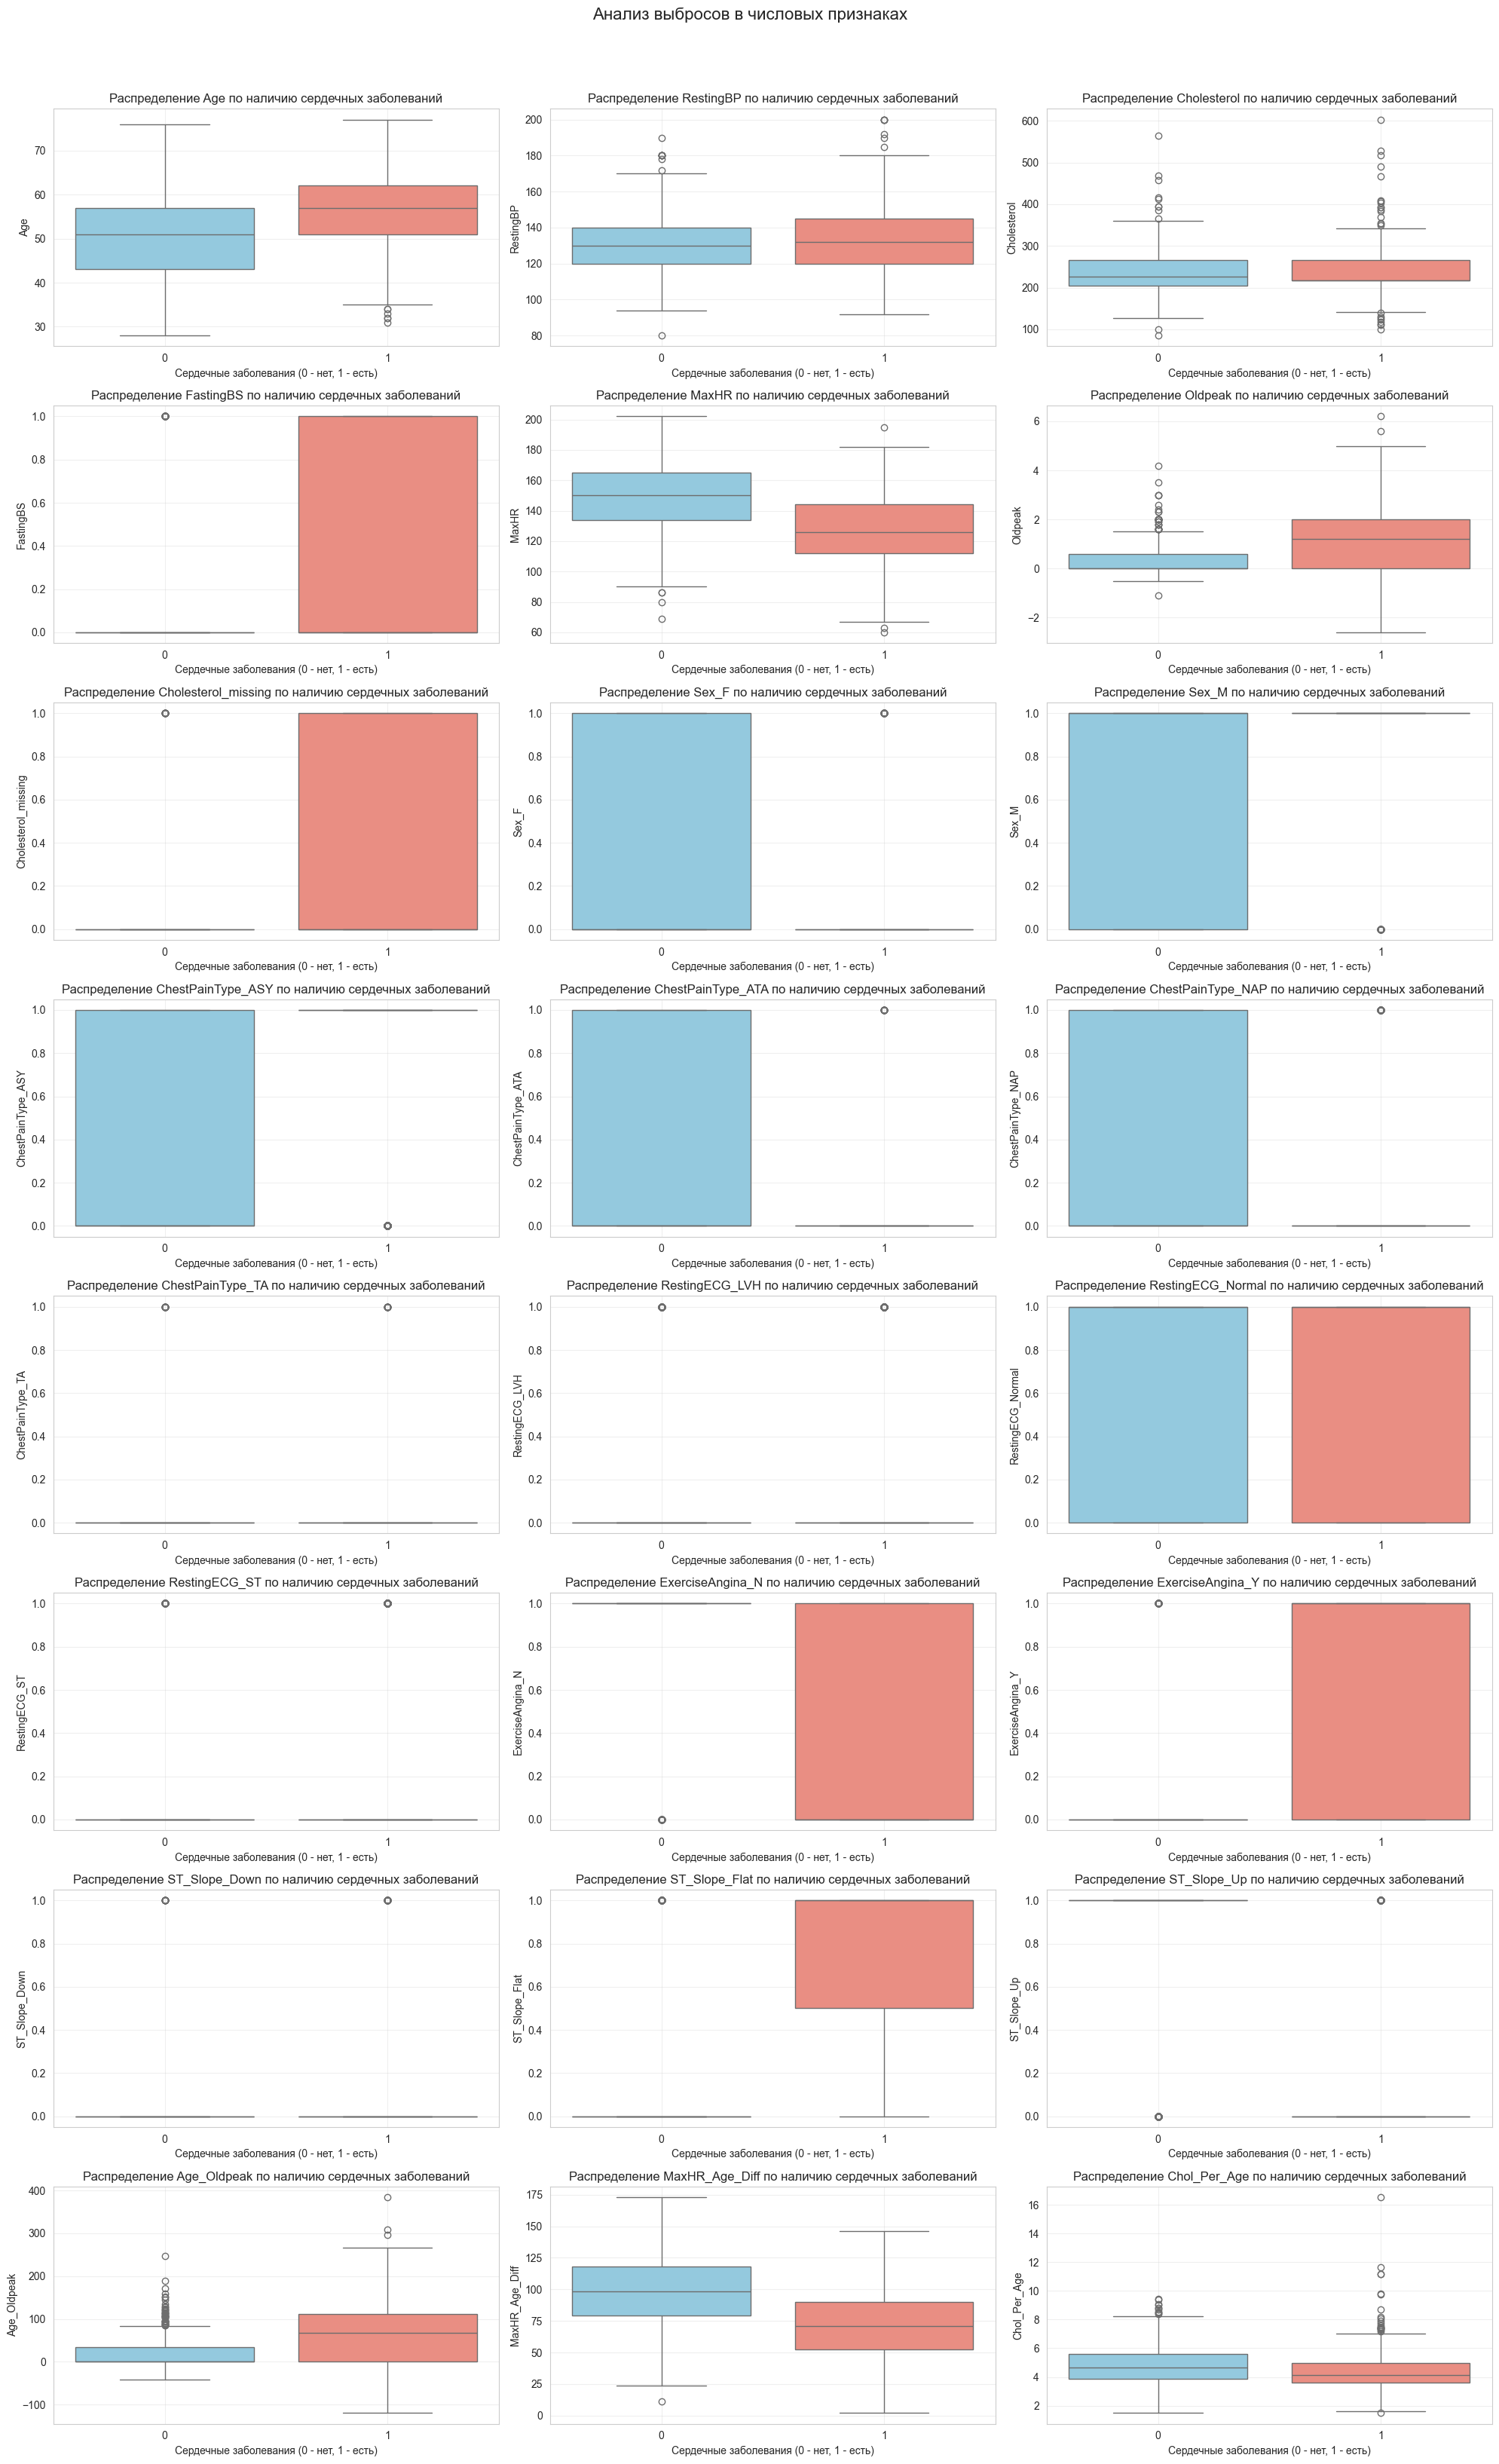

In [91]:
# Функция для построения box plots для обнаружения выбросов
def plot_boxplots(dataframe, n_cols=3, exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = []
    
    # Выбираем только числовые признаки для анализа
    numeric_cols = num_cols
    
    # Исключаем указанные колонки
    features_to_plot = [col for col in numeric_cols if col not in exclude_cols]
    
    n_rows = int(np.ceil(len(features_to_plot) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    axes = axes.flatten()
    
    for i, feature in enumerate(features_to_plot):
        ax = axes[i]
        
        sns.boxplot(data=dataframe, x='HeartDisease', y=feature, 
                   hue='HeartDisease',
                   palette=['skyblue', 'salmon'],
                   legend=False,
                   ax=ax)
        
        # Настраиваем внешний вид
        ax.set_title(f'Распределение {feature} по наличию сердечных заболеваний', fontsize=12)
        ax.set_xlabel('Сердечные заболевания (0 - нет, 1 - есть)')
        ax.set_ylabel(feature)
        
        # Добавляем сетку для лучшей читаемости
        ax.grid(True, alpha=0.3)
    
    # Скрываем неиспользованные оси
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle('Анализ выбросов в числовых признаках', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


exclude_from_plots = []  # сюда колонки, которые не включать

outliers_info = plot_boxplots(df, exclude_cols=exclude_from_plots)

Heatmap корреляций.

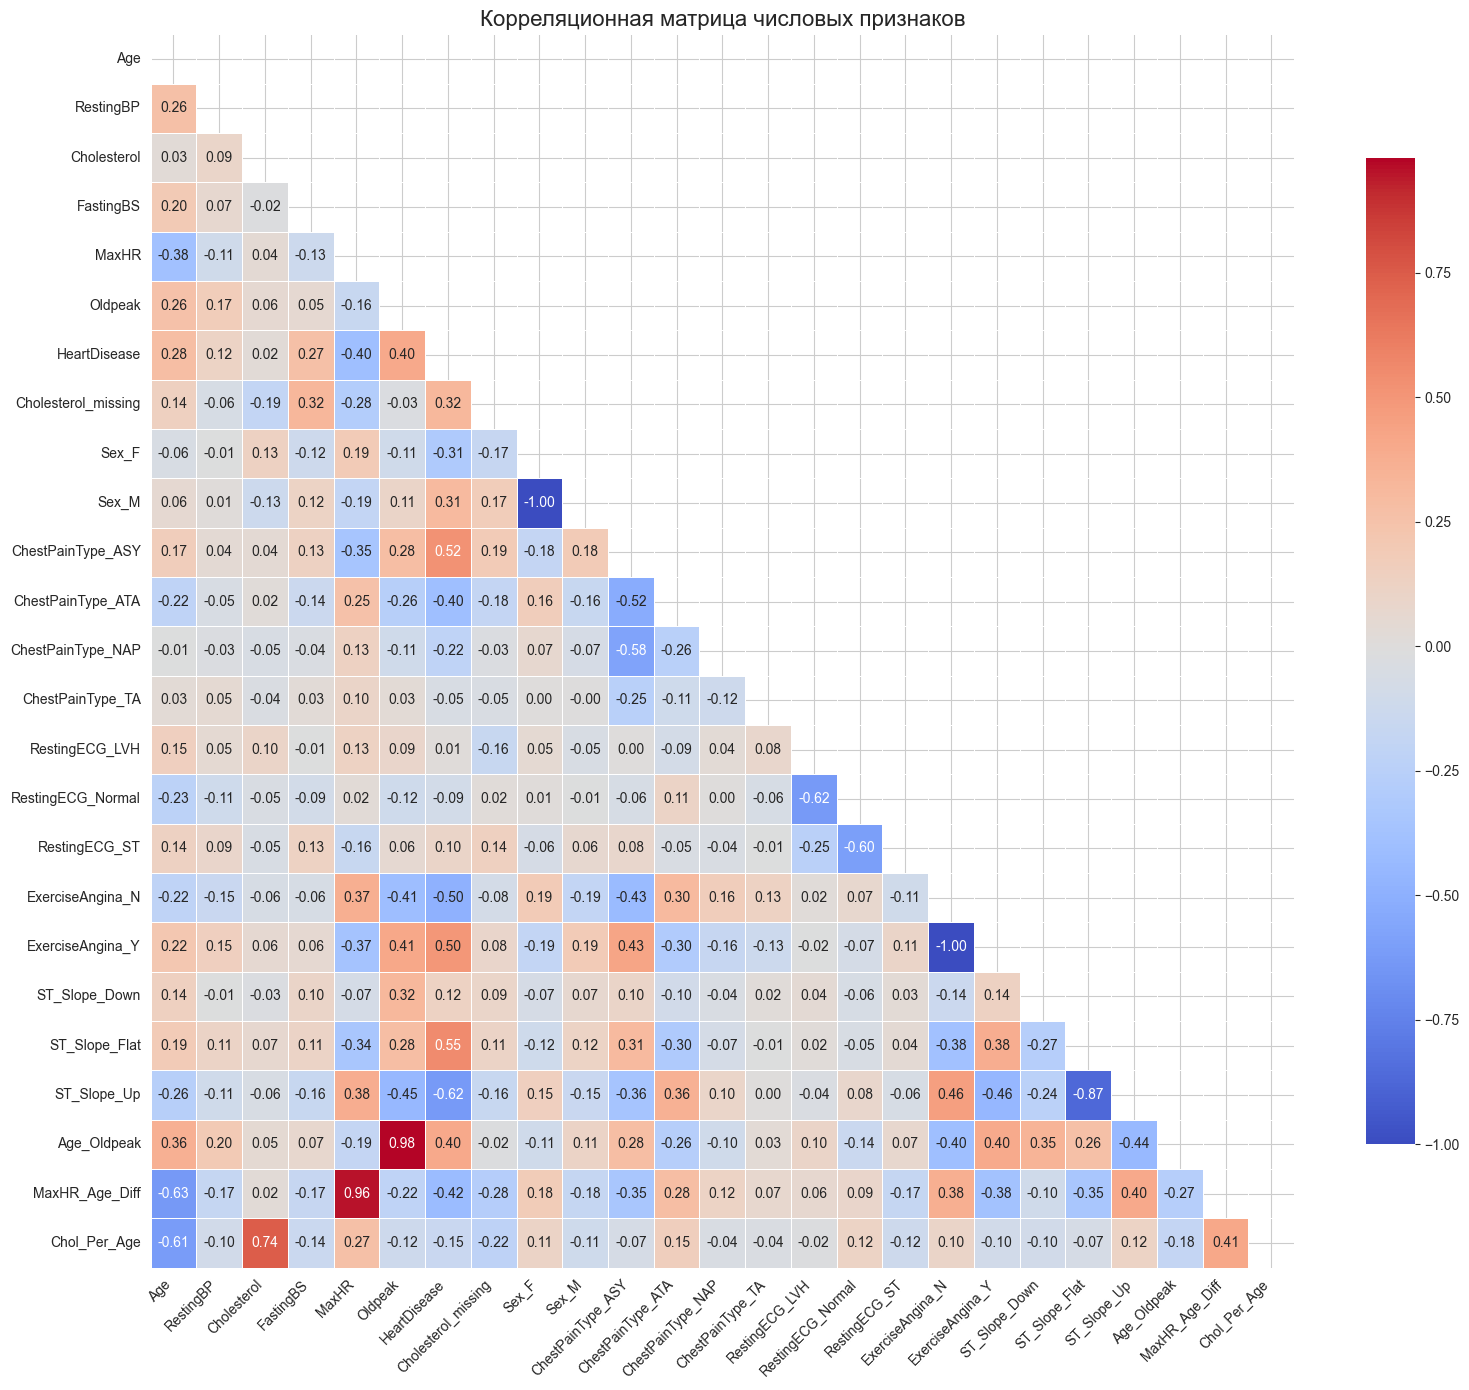

In [92]:
# Построение корреляционной матрицы
plt.figure(figsize=(16, 14))

correlation_matrix = df.select_dtypes(include=[np.number]).corr()

mask = np.triu(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Корреляционная матрица числовых признаков', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Корреляция признаков с целевой переменной:
HeartDisease           1.000000
ST_Slope_Flat          0.553700
ChestPainType_ASY      0.518339
ExerciseAngina_Y       0.495490
Age_Oldpeak            0.403984
Oldpeak                0.403638
Cholesterol_missing    0.317918
Sex_M                  0.305118
Age                    0.282012
FastingBS              0.267994
ST_Slope_Down          0.122852
RestingBP              0.117990
RestingECG_ST          0.103067
Cholesterol            0.024914
RestingECG_LVH         0.011174
ChestPainType_TA      -0.054591
RestingECG_Normal     -0.092452
Chol_Per_Age          -0.148797
ChestPainType_NAP     -0.215311
Sex_F                 -0.305118
MaxHR                 -0.401410
ChestPainType_ATA     -0.401680
MaxHR_Age_Diff        -0.424458
ExerciseAngina_N      -0.495490
ST_Slope_Up           -0.621843
Name: HeartDisease, dtype: float64


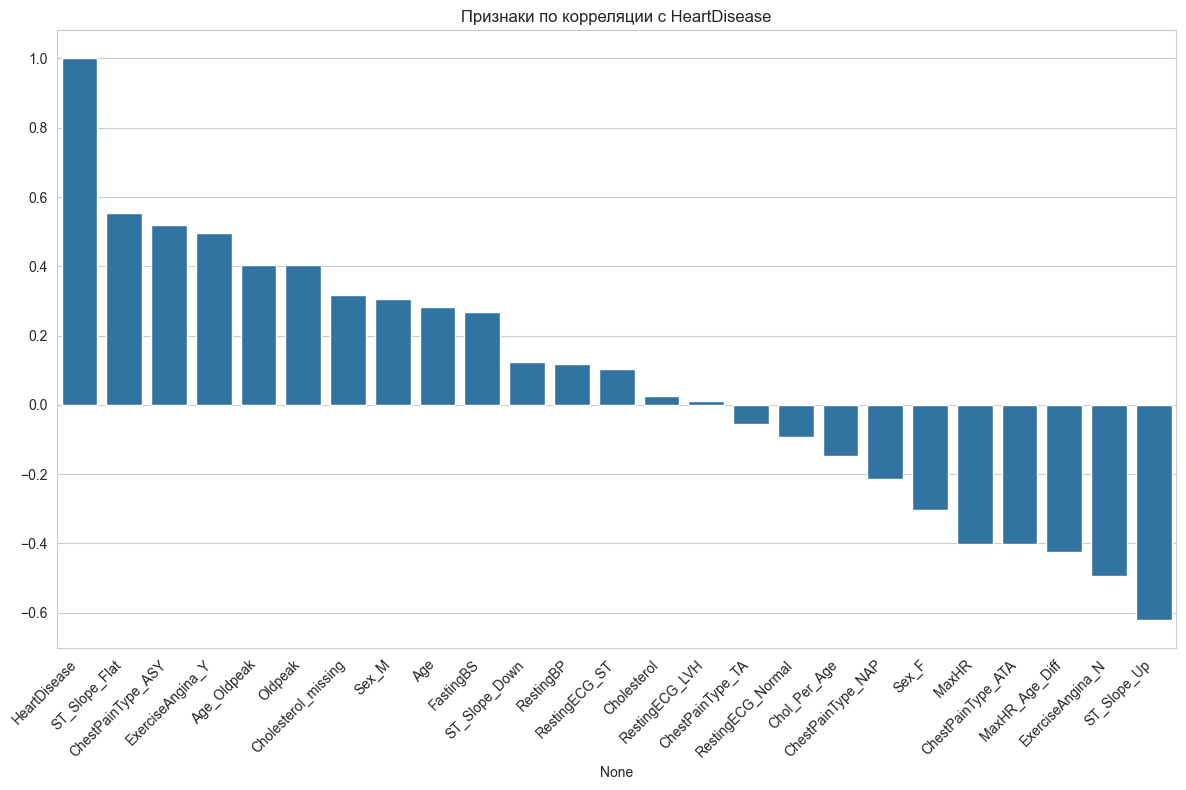

In [93]:
# Расчет корреляции признаков с целевой переменной
target_correlation = correlation_matrix['HeartDisease'].sort_values(ascending=False)
print("\nКорреляция признаков с целевой переменной:")
print(target_correlation)

# Визуализация топ-10 признаков по корреляции с целевой переменной
plt.figure(figsize=(12, 8))
sns.barplot(x=target_correlation.index[:], y=target_correlation.values[:])
plt.title('Признаки по корреляции с HeartDisease')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [94]:
for col in correlation_matrix:
    col_corr = correlation_matrix[col].sort_values(ascending=False)
    # Фильтруем значения по модулю больше 0.25
    filtered = col_corr[abs(col_corr) > 0.25]
    # Убираем сам признак
    filtered = filtered[filtered.index != col]
    
    if not filtered.empty:
        print(f"\nКорреляции для {col} (>|0.25|):")
        for idx, val in filtered.items():
            print(f"  {idx}: {val:.3f}")


Корреляции для Age (>|0.25|):
  Age_Oldpeak: 0.365
  HeartDisease: 0.282
  RestingBP: 0.263
  Oldpeak: 0.259
  ST_Slope_Up: -0.258
  MaxHR: -0.382
  Chol_Per_Age: -0.613
  MaxHR_Age_Diff: -0.632

Корреляции для RestingBP (>|0.25|):
  Age: 0.263

Корреляции для Cholesterol (>|0.25|):
  Chol_Per_Age: 0.742

Корреляции для FastingBS (>|0.25|):
  Cholesterol_missing: 0.325
  HeartDisease: 0.268

Корреляции для MaxHR (>|0.25|):
  MaxHR_Age_Diff: 0.958
  ST_Slope_Up: 0.384
  ExerciseAngina_N: 0.370
  Chol_Per_Age: 0.266
  ChestPainType_ATA: 0.254
  Cholesterol_missing: -0.282
  ST_Slope_Flat: -0.344
  ChestPainType_ASY: -0.354
  ExerciseAngina_Y: -0.370
  Age: -0.382
  HeartDisease: -0.401

Корреляции для Oldpeak (>|0.25|):
  Age_Oldpeak: 0.981
  ExerciseAngina_Y: 0.409
  HeartDisease: 0.404
  ST_Slope_Down: 0.322
  ST_Slope_Flat: 0.283
  ChestPainType_ASY: 0.281
  Age: 0.259
  ChestPainType_ATA: -0.262
  ExerciseAngina_N: -0.409
  ST_Slope_Up: -0.450

Корреляции для HeartDisease (>|0.25|):

**Признаки по корреляции с HeartDisease показаны на графике**

**Корреляция между другими колонками:**  

**Сильная корреляция (>0.7):**
- Oldpeak - Age_Oldpeak: **0.981** *(наш новый признак)*
- MaxHR - MaxHR_Age_Diff: **0.958** *(наш новый признак)*
- Cholesterol - Chol_Per_Age: **0.742** *(наш новый признак)*

**Средняя корреляция (0.4 – 0.7):**
- Age - MaxHR_Age_Diff: **-0.632** *(наш новый признак)*
- Age - Chol_Per_Age: **-0.613** *(наш новый признак)*
- RestingECG_LVH - RestingECG_Normal: **-0.623**
- RestingECG_Normal - RestingECG_ST: **-0.602**
- ChestPainType_ASY - ChestPainType_NAP: **-0.577**
- ChestPainType_ASY - ChestPainType_ATA: **-0.523**
- ExerciseAngina_N - ExerciseAngina_Y: **-1.000**
- ST_Slope_Up - ST_Slope_Flat: **-0.871**
- MaxHR_Age_Diff - Chol_Per_Age: **0.414**

**Слабые корреляции (0.25 – 0.4):**
- Age - Age_Oldpeak: **0.365** *(наш новый признак)*
- Age - MaxHR: **-0.382**
- MaxHR - ST_Slope_Up: **0.384**
- MaxHR - ExerciseAngina_N: **0.370**
- MaxHR - ChestPainType_ASY: **-0.354**
- MaxHR - ST_Slope_Flat: **-0.344**
- Oldpeak - ExerciseAngina_Y: **0.409**
- Oldpeak - ST_Slope_Down: **0.322**
- Oldpeak - ST_Slope_Flat: **0.283**
- Oldpeak - ChestPainType_ASY: **0.281**
- FastingBS - Cholesterol_missing: **0.325**
- Age - RestingBP: **0.263**
- Age - Oldpeak: **0.259**

Scatter plot - ищем зависимости между ключевыми признаками.

Построение scatter matrix для топ-10 признаков: ['ST_Slope_Flat', 'ChestPainType_ASY', 'ExerciseAngina_Y', 'Age_Oldpeak', 'Oldpeak', 'Cholesterol_missing', 'Sex_M', 'Age', 'FastingBS', 'ST_Slope_Down', 'RestingBP']


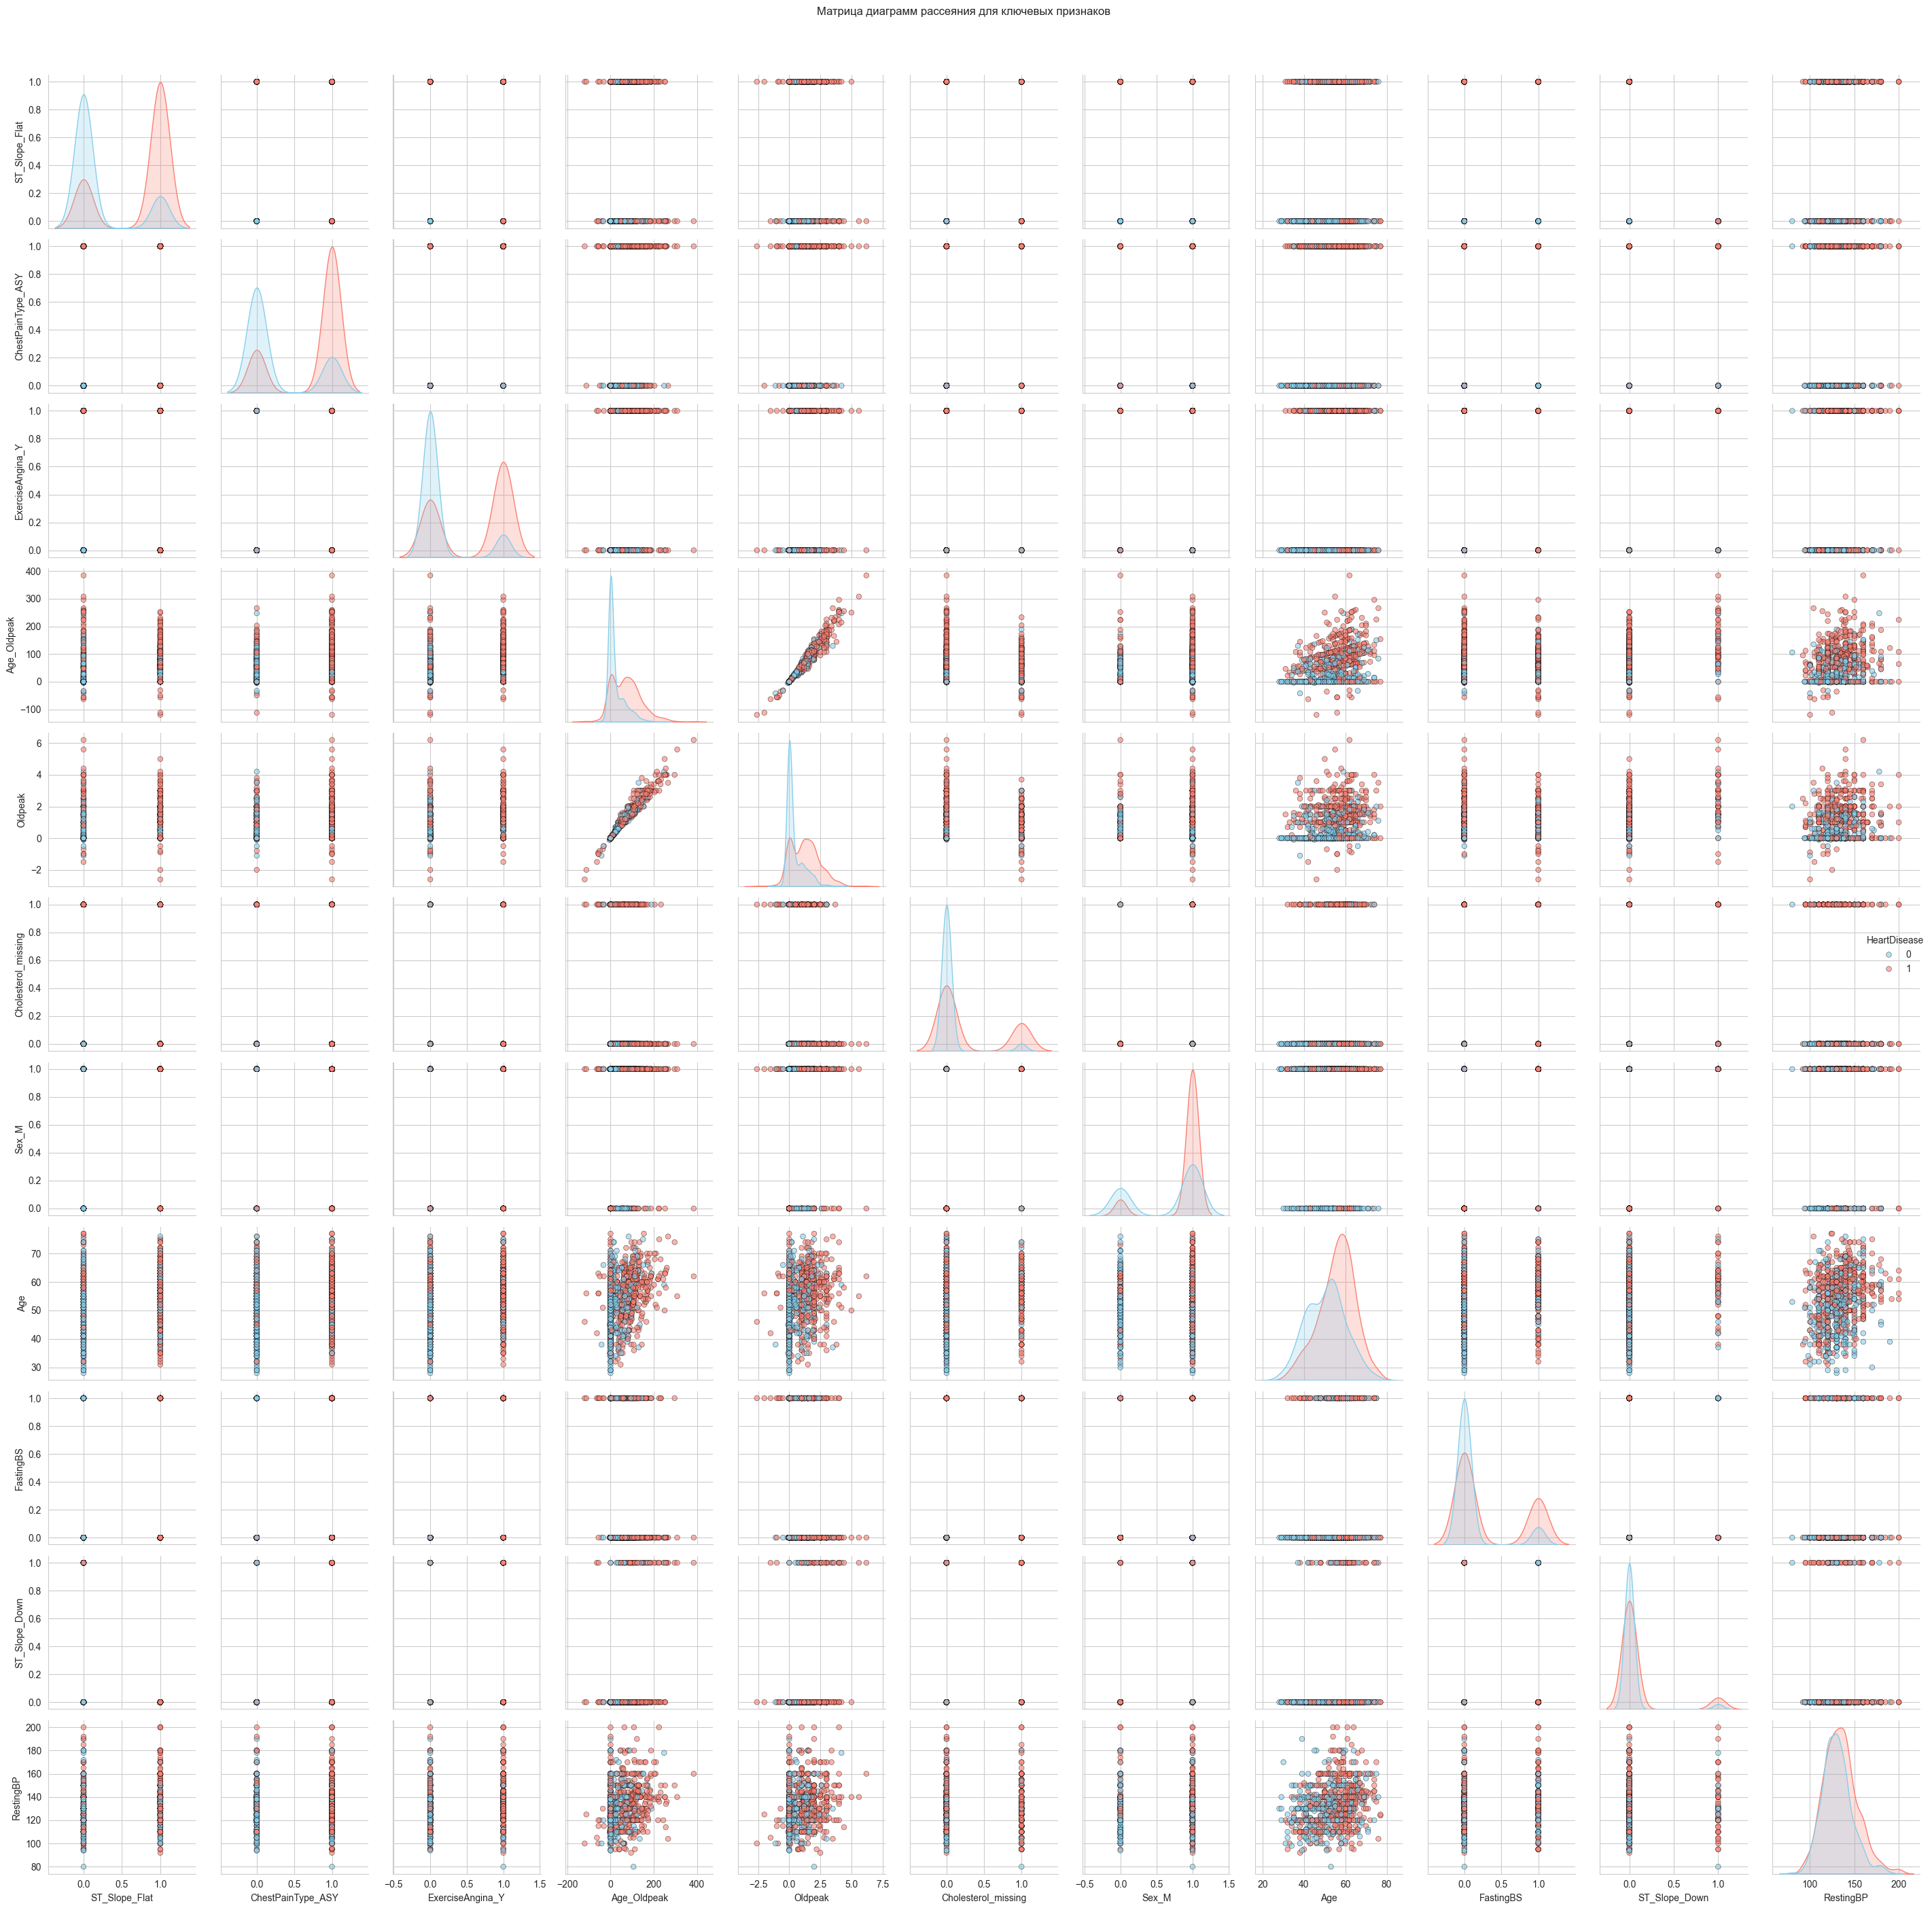

In [96]:
# Функция для построения scatter plots для пар признаков
def plot_scatter_matrix(dataframe, features, target_col='HeartDisease'):
    # Создаем подвыборку данных для более быстрой визуализации
    if len(dataframe) > 1000:
        sample_df = dataframe.sample(1000, random_state=42)
    else:
        sample_df = dataframe

    # Создаем pairplot для выбранных признаков
    sns.pairplot(data=sample_df, vars=features, hue=target_col, diag_kind='kde',
                palette=['skyblue', 'salmon'], plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'})
    plt.suptitle('Матрица диаграмм рассеяния для ключевых признаков', y=1.02)
    plt.tight_layout()
    plt.show()
    
top_features = [col for col in target_correlation.index if col != 'HeartDisease'][:11]
print(f"Построение scatter matrix для топ-10 признаков: {top_features}")
plot_scatter_matrix(df, top_features)

Bar/count plot для категорий.

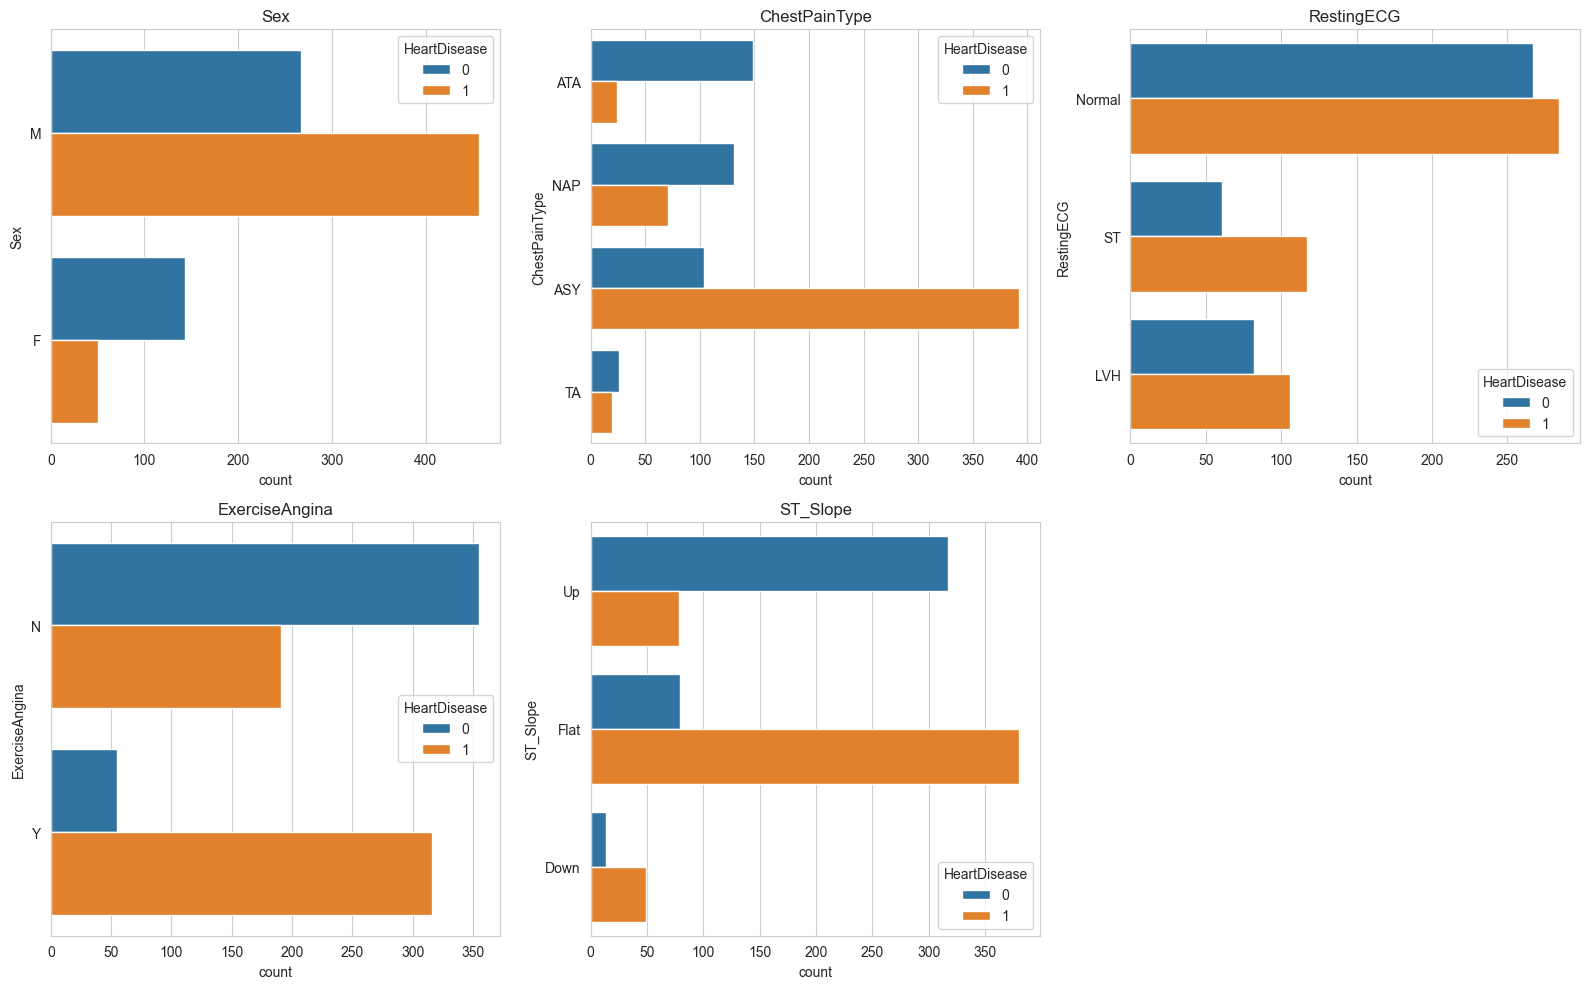

In [102]:
df_plot = df.copy()

# группы one-hot колонок
groups = {
    'Sex': ['Sex_F','Sex_M'],
    'ChestPainType': ['ChestPainType_ASY','ChestPainType_ATA','ChestPainType_NAP','ChestPainType_TA'],
    'RestingECG': ['RestingECG_LVH','RestingECG_Normal','RestingECG_ST'],
    'ExerciseAngina': ['ExerciseAngina_N','ExerciseAngina_Y'],
    'ST_Slope': ['ST_Slope_Down','ST_Slope_Flat','ST_Slope_Up']
}

# восстанавливаем категории
for name, cols in groups.items():
    df_plot[name] = df_plot[cols].idxmax(axis=1).str.replace(f'{name}_','')

# создаем сетку графиков
fig, axes = plt.subplots(2, 3, figsize=(16,10))
axes = axes.flatten()

for i, col in enumerate(groups.keys()):
    sns.countplot(data=df_plot, y=col, hue='HeartDisease', ax=axes[i])
    axes[i].set_title(col)

# удаляем пустой график
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

### Выводы
### Что я понял про датасет

- Датасет содержит медицинские признаки пациентов (возраст, давление, холестерин, результаты ЭКГ и нагрузочных тестов) и целевую переменную `HeartDisease`, показывающую наличие заболевания сердца.
- В данных присутствуют как числовые, так и категориальные признаки; категориальные признаки были закодированы с помощью pd.get_dummies().
- Большинство признаков имеют слабую или умеренную корреляцию между собой, однако некоторые новые признаки, созданные в ходе feature engineering, имеют сильную корреляцию с исходными переменными.
- Наиболее сильная корреляция между признаками наблюдается у пар `Oldpeak – Age_Oldpeak`, `MaxHR – MaxHR_Age_Diff` и `Cholesterol – Chol_Per_Age`, что ожидаемо, поскольку новые признаки вычисляются на основе исходных.
- Среди признаков наибольшую корреляцию с целевой переменной показывают `ST_Slope_Flat`, `ChestPainType_ASY`, `ExerciseAngina_Y`, `Oldpeak` и `Age_Oldpeak`.
- Отрицательная корреляция с `HeartDisease` наблюдается у признаков `ST_Slope_Up`, `MaxHR`, `ChestPainType_ATA` и `ExerciseAngina_N`.
- Признаки, связанные с нагрузочным тестом (`ST_Slope`, `ExerciseAngina`, `Oldpeak`, `MaxHR`), оказываются наиболее информативными для определения наличия сердечного заболевания.
- В данных присутствуют производные признаки (`Age_Oldpeak`, `MaxHR_Age_Diff`, `Chol_Per_Age`), которые могут отражать более сложные зависимости между медицинскими показателями.
- Некоторые признаки имеют очень сильную корреляцию между собой, что может указывать на мультиколлинеарность.
- В целом датасет выглядит достаточно чистым и хорошо подходит для задач классификации.

---

### Гипотезы и наблюдения

- Пациенты с типом боли в груди `ASY` чаще имеют сердечное заболевание, чем пациенты с другими типами боли.
- Наличие стенокардии при нагрузке (`ExerciseAngina = Y`) связано с более высокой вероятностью сердечного заболевания.
- Более высокий показатель `Oldpeak` (депрессия ST-сегмента) может быть индикатором ишемической болезни сердца.
- Пациенты с более низким максимальным пульсом (`MaxHR`) чаще имеют заболевание сердца.
- Производные признаки, учитывающие возраст пациента (`Age_Oldpeak`, `MaxHR_Age_Diff`), могут лучше отражать физиологические ограничения и поэтому сильнее связаны с риском заболевания.

---

### Что бы я сделал дальше

- Построил бы модель классификации для предсказания наличия сердечного заболевания (`HeartDisease`).
- В качестве базовой модели попробовал бы **Logistic Regression**, чтобы получить интерпретируемые коэффициенты признаков.
- Далее протестировал бы более мощные алгоритмы, такие как **Random Forest** или **Gradient Boosting**, которые лучше работают с нелинейными зависимостями.
- Провёл бы отбор признаков, чтобы убрать сильно коррелирующие переменные и уменьшить мультиколлинеарность.
- Оценивал бы качество модели с помощью метрик **ROC-AUC**, **F1-score** и **confusion matrix**.
- Также можно было бы исследовать важность признаков (feature importance) для лучшего понимания факторов риска сердечных заболеваний.

### Использование AI

При выполнении анализа я использовал AI, в основном подсказки касались **визуализации данных**: примеров построения графиков в `matplotlib` и `seaborn`.
- код визуализации я адаптировал под структуру своего датасета
- проверял корректность графиков и интерпретацию результатов самостоятельно;
- часть кода была упрощена, чтобы лучше соответствовать задачам EDA;
- аналитические выводы и интерпретация результатов были сделаны самостоятельно на основе полученных графиков и корреляций.